### Implementação do DBSCAN
Primeiro, precisamos estimar o parâmetro **Epsilon (eps)** utilizando o Gráfico k-distance (método do cotovelo para vizinhos). Para um dataset bidimensional (2D), a diretriz prática sugerida na aula é fixar **minPts = 5**.

In [29]:
# 1. Importação das bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [30]:
# =========================
# 1. CARREGAR DADOS
# =========================
df = pd.read_csv(
    r"C:\Users\gques\Documents\SPTECH_CODIGOS\ultimo-ano\tcc\backend\tabela_final\part-00000-ca4a34f2-1bd8-485a-bddf-3084ae83539c-c000.csv"
)

# =========================
# 2. SPLIT TEMPORAL
# =========================
split_date = pd.to_datetime("2018-07-01", utc=True)

date_col = pd.to_datetime(
    df["order_delivered_carrier_date"],
    utc=True
)

train_mask = date_col < split_date
test_mask = date_col >= split_date

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f"Treino: {len(df_train):,} linhas")
print(f"Teste: {len(df_test):,} linhas")

# =========================
# 3. FEATURES
# =========================
colunas_remover = [
    # Vazamento de dados / multicolinearidade
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "interval_code_delivered_carrier",
    "order_delivered_customer_date",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "delivered_on_time",
    "customer_city",
    "seller_city",
    "category_name",
    "review_score"
]

X_train = df_train.drop(columns=colunas_remover)
X_test = df_test.drop(columns=colunas_remover)

y_train = df_train["delivered_on_time"]
y_test = df_test["delivered_on_time"]

# =========================
# 4. TRATAMENTO DE NULOS
# =========================
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print("\nShape treino:", X_train.shape)
print("Shape teste:", X_test.shape)

print("\nColunas utilizadas:")
print(X_train.columns.tolist())

Treino: 28,710 linhas
Teste: 5,114 linhas

Shape treino: (28710, 13)
Shape teste: (5114, 13)

Colunas utilizadas:
['holiday_at_purchase', 'days_since_last_holiday', 'days_until_next_holiday', 'purchase_hour', 'purchase_day_of_week', 'is_weekend', 'delivery_time_days', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city']


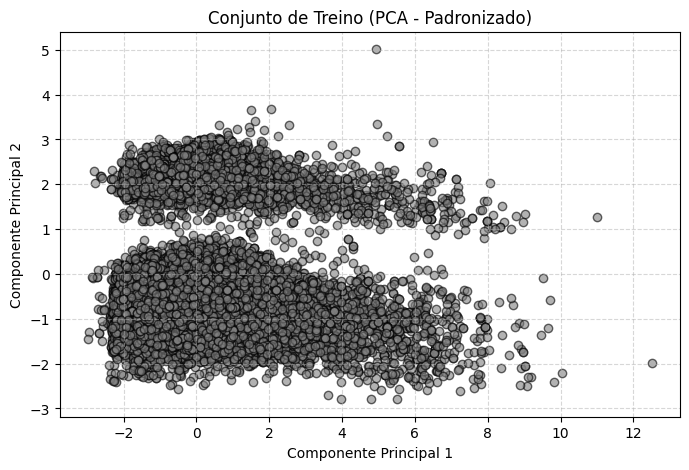

In [31]:

# =========================
# PADRONIZAÇÃO DOS DADOS
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# REDUÇÃO PARA 2 DIMENSÕES
# (apenas para visualização)
# =========================
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# =========================
# VISUALIZAÇÃO DOS DADOS DE TREINO
# =========================
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c='gray',
    alpha=0.6,
    edgecolors='k'
)

plt.title('Conjunto de Treino (PCA - Padronizado)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

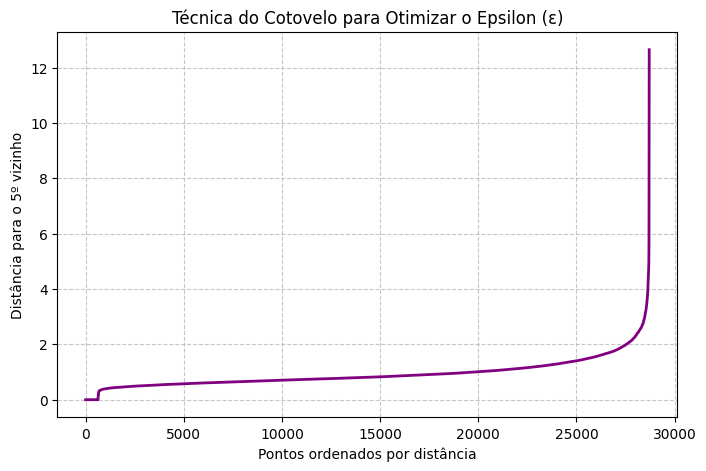

Percentil 90: 1.532
Percentil 95: 1.886
Percentil 99: 2.823


In [32]:
# =========================
# ESTIMATIVA DO EPSILON (ε)
# UTILIZANDO A TÉCNICA DO COTOVELO
# =========================

# Define o número mínimo de amostras que um ponto precisa ter
# em sua vizinhança para ser considerado um ponto central pelo DBSCAN.
min_samples = 5

# Cria o modelo para encontrar os k vizinhos mais próximos
# de cada registro da base.
neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

# Ajusta o modelo aos dados de treino padronizados.
neighbors_fit = neighbors.fit(X_train_scaled)

# Para cada registro, calcula:
# - distances: distância para cada um dos k vizinhos mais próximos
# - indices: posição desses vizinhos na base
distances, indices = neighbors_fit.kneighbors(
    X_train_scaled
)

# Seleciona a distância até o 5º vizinho mais próximo
# (posição min_samples - 1 porque a contagem começa em zero)
# e ordena essas distâncias em ordem crescente.
k_distances = np.sort(
    distances[:, min_samples - 1]
)

# =========================
# GRÁFICO DO COTOVELO
# =========================

plt.figure(figsize=(8, 5))

# Plota as distâncias ordenadas.
# O ponto onde ocorre uma mudança brusca de inclinação
# ("cotovelo") é um bom candidato para o valor de epsilon.
plt.plot(
    k_distances,
    color='purple',
    linewidth=2
)

plt.title(
    'Técnica do Cotovelo para Otimizar o Epsilon (ε)'
)

plt.xlabel(
    'Pontos ordenados por distância'
)

plt.ylabel(
    f'Distância para o {min_samples}º vizinho'
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.7
)

plt.show()

# =========================
# PERCENTIS DAS DISTÂNCIAS
# =========================

# Exibe alguns percentis das distâncias calculadas.
# Esses valores podem servir como candidatos para o epsilon,
# especialmente quando o cotovelo não é visualmente evidente.

print(
    f"Percentil 90: {np.percentile(k_distances,90):.3f}"
)

print(
    f"Percentil 95: {np.percentile(k_distances,95):.3f}"
)

print(
    f"Percentil 99: {np.percentile(k_distances,99):.3f}"
)

In [33]:
# Importa o classificador KNN e a métrica F1-Score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# Lista que armazenará os resultados de cada valor de epsilon testado
resultados = []

# Testa diferentes valores de epsilon para o DBSCAN
for eps in [1.5, 2.0, 2.5, 3.0]:

    # =========================
    # EXECUÇÃO DO DBSCAN
    # =========================

    # Cria o modelo DBSCAN com o epsilon atual
    # e o número mínimo de amostras definido como 5
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    # Executa o agrupamento e retorna os rótulos dos clusters
    # Cluster >= 0 = pertence a um cluster
    # Cluster = -1 = considerado outlier (ruído)
    labels = dbscan.fit_predict(
        X_train_scaled
    )

    # Calcula a quantidade de clusters encontrados
    # Desconsiderando o cluster -1 (outliers)
    clusters = (
        len(set(labels))
        - (1 if -1 in labels else 0)
    )

    # Conta quantos registros foram classificados como outliers
    noise = np.sum(labels == -1)

    # =========================
    # REMOÇÃO DOS OUTLIERS
    # =========================

    # Cria uma máscara para manter apenas os registros
    # que pertencem a algum cluster válido
    mask = labels != -1

    # Gera um novo conjunto de treino sem os outliers
    X_train_clean = X_train_scaled[mask]

    # Mantém apenas os rótulos correspondentes aos registros válidos
    y_train_clean = y_train.values[mask]

    # =========================
    # TREINAMENTO DO KNN
    # =========================

    # Cria o modelo KNN
    # n_neighbors=4 -> utiliza os 4 vizinhos mais próximos
    # weights='distance' -> vizinhos mais próximos possuem maior peso
    knn = KNeighborsClassifier(
        n_neighbors=4,
        weights='distance'
    )

    # Treina o modelo utilizando apenas os dados
    # que permaneceram após a remoção dos outliers
    knn.fit(
        X_train_clean,
        y_train_clean
    )

    # =========================
    # PREDIÇÃO
    # =========================

    # Realiza as previsões para o conjunto de teste
    y_pred = knn.predict(
        X_test_scaled
    )

    # =========================
    # AVALIAÇÃO
    # =========================

    # Calcula o F1-Score ponderado.
    # Essa métrica considera simultaneamente
    # Precision e Recall e é adequada para
    # conjuntos com possível desbalanceamento.
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Armazena os resultados para posterior análise
    resultados.append([
        eps,
        clusters,
        noise,
        f1
    ])

    # Exibe os resultados obtidos para o epsilon atual
    print(
        f"eps={eps} | "
        f"clusters={clusters} | "
        f"outliers={noise} | "
        f"f1={f1:.4f}"
    )

eps=1.5 | clusters=41 | outliers=2155 | f1=0.8253
eps=2.0 | clusters=20 | outliers=726 | f1=0.8269
eps=2.5 | clusters=9 | outliers=280 | f1=0.8269
eps=3.0 | clusters=6 | outliers=130 | f1=0.8269


mostram que:

Quando removeu muitos registros (eps=1.5), o KNN perdeu desempenho.
Para eps >= 2.0, a remoção de outliers não trouxe ganho nem perda perceptível.
O melhor F1 encontrado foi 0.8269.

In [34]:
resultado_eps = pd.DataFrame(
    resultados,
    columns=[
        "eps",
        "clusters",
        "outliers",
        "f1"
    ]
)

resultado_eps.sort_values(
    "f1",
    ascending=False
)

,eps,clusters,outliers,f1
1,2.0,20,726,0.826874
2,2.5,9,280,0.826874
3,3.0,6,130,0.826874
0,1.5,41,2155,0.825282


Esse resultado mostra o impacto que cada valor de epsilon (eps) teve no DBSCAN e, consequentemente, no desempenho do KNN após a remoção dos outliers.

In [35]:
best_eps = resultado_eps.loc[
    resultado_eps["f1"].idxmax(),
    "eps"
]

print(
    f"Melhor epsilon encontrado: {best_eps}"
)

Melhor epsilon encontrado: 2.0


In [36]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_train_scaled
)

num_clusters = (
    len(set(dbscan_labels))
    - (1 if -1 in dbscan_labels else 0)
)

num_noise = np.sum(
    dbscan_labels == -1
)

print(
    f"Clusters encontrados: {num_clusters}"
)

print(
    f"Outliers encontrados: {num_noise}"
)

Clusters encontrados: 20
Outliers encontrados: 726


Foram avaliados diferentes valores do parâmetro epsilon do DBSCAN (1.5, 2.0, 2.5 e 3.0). Para cada configuração, os registros identificados como outliers foram removidos do conjunto de treinamento antes da aplicação do classificador KNN. Observou-se que o valor 1.5 classificou 2155 registros como outliers, reduzindo levemente o desempenho do modelo (F1-Score = 0,8253). Já os valores 2.0, 2.5 e 3.0 apresentaram o mesmo F1-Score (0,8269), indicando que a remoção adicional de registros não trouxe benefícios ao classificador. Dessa forma, foi adotado o valor ε = 2.0, por apresentar o melhor equilíbrio entre identificação de outliers e desempenho preditivo.

Sem o KNN você teria apenas:
eps=1.5 → 41 clusters
eps=2.0 → 20 clusters
eps=2.5 → 9 clusters
eps=3.0 → 6 clusters

Mas não saberia responder:
"Qual desses agrupamentos melhora a capacidade de prever atrasos?"

Com o KNN você conseguiu medir isso.

O KNN mostrou que:
Remover 2155 registros (eps=1.5)
↓
prejudica a previsão
porque o F1 caiu.

Remover 726 registros (eps=2.0)
Remover 280 registros (eps=2.5)
Remover 130 registros (eps=3.0)
↓
não altera o desempenho

O KNN serviu para validar que:

alguns registros classificados como outliers eram úteis para a previsão;
remover outliers em excesso piora o modelo;
a maioria dos outliers encontrados pelo DBSCAN não estava afetando significativamente a classificação.